In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [51]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [52]:
df.shape

(545, 13)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [54]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [55]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [56]:
df.drop(columns=['furnishingstatus'], inplace=True)

In [57]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no
541,1767150,2400,3,1,1,no,no,no,no,no,0,no
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no
543,1750000,2910,3,1,1,no,no,no,no,no,0,no


In [ ]:
columns_to_transform = ['mainroad', 'guestroom', 'basement','hotwaterheating', 'airconditioning','stories', 'prefarea']
df[columns_to_transform] = df[columns_to_transform].replace({'yes': 1, 'no': 0})


In [61]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
8,3.230720,1.598107,4,1,2,1,1,1,0,1,2,1
9,3.187833,0.379629,3,2,4,1,1,0,0,1,1,1
12,2.887628,0.794430,4,2,2,1,0,0,0,1,1,1
14,2.844742,1.442556,3,2,2,1,0,0,0,0,0,1
15,2.758969,0.509254,4,1,2,1,0,1,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,-1.701226,-1.046249,2,1,1,1,0,1,0,0,2,0
541,-1.733606,-1.357350,3,1,1,0,0,0,0,0,0,0
542,-1.744113,-0.724778,2,1,1,1,0,0,0,0,0,0
543,-1.744113,-1.092914,3,1,1,0,0,0,0,0,0,0


In [62]:
df.dtypes

price              float64
area               float64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad             int64
guestroom            int64
basement             int64
hotwaterheating      int64
airconditioning      int64
parking              int64
prefarea             int64
dtype: object

In [59]:
import scipy.stats as stats
z_scores = stats.zscore(df)
threashold = 3
print("size before removing outliers: ", df.shape)
outlaiers = df[(z_scores > threashold).any(axis=1)]
df = df[(z_scores<= threashold).all(axis=1)]
print("size after removing outliers: ", df.shape)

size before removing outliers:  (545, 12)
size after removing outliers:  (499, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
sc = ['price', 'area']
df[sc] = scaler.fit_transform(df[sc])

In [63]:
corr_matrix = df.corr()

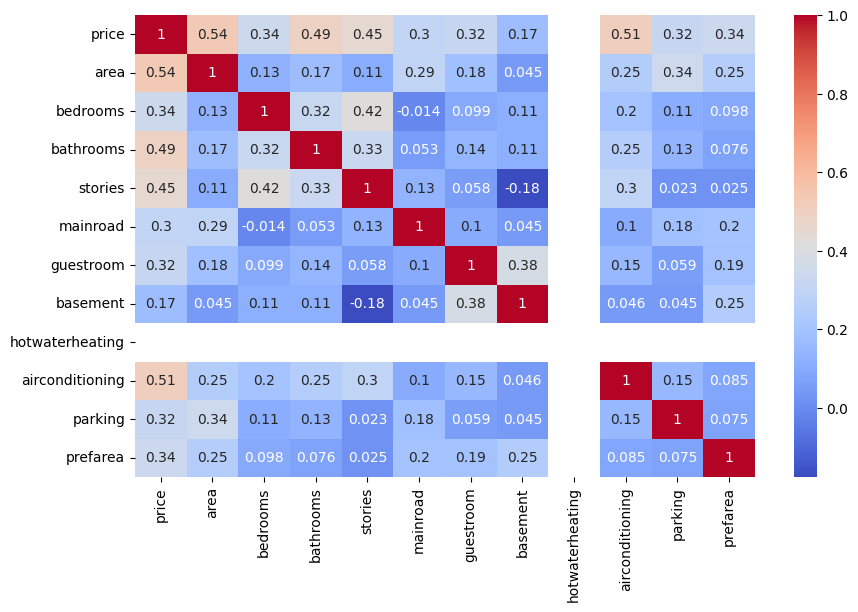

In [64]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [65]:
X = df.drop('price', axis=1)
y = df['price']

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

In [68]:
lr_y_pred = lr_model.predict(X_test)

In [70]:
from sklearn.metrics import r2_score
lr_accuracy = r2_score(y_test, lr_y_pred)*100
lr_accuracy

66.77456376657804

In [71]:
import joblib
joblib.dump(lr_model, 'house_price_model.jb')

['house_price_model.jb']